# 07 — Visualization gallery

Các biểu đồ mẫu (dữ liệu tổng hợp / giả lập) để tham chiếu khi báo cáo:

- Radar chart (mạng nhện)
- Bar chart — BERTScore (Precision / Recall / F1)
- Heatmap
- 3D training plot
- Training curves (Accuracy & Loss)
- t-SNE visualization

Chạy từ thư mục `notebooks/`. Ảnh có thể lưu vào `../reports/`.

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — cần cho 3D
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
REPORTS = ROOT / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

RNG = np.random.default_rng(42)

## 1. Radar chart (biểu đồ mạng nhện)

So sánh vài mô hình trên các trục đã chuẩn hóa về \[0, 1\] (càng xa tâm càng tốt).

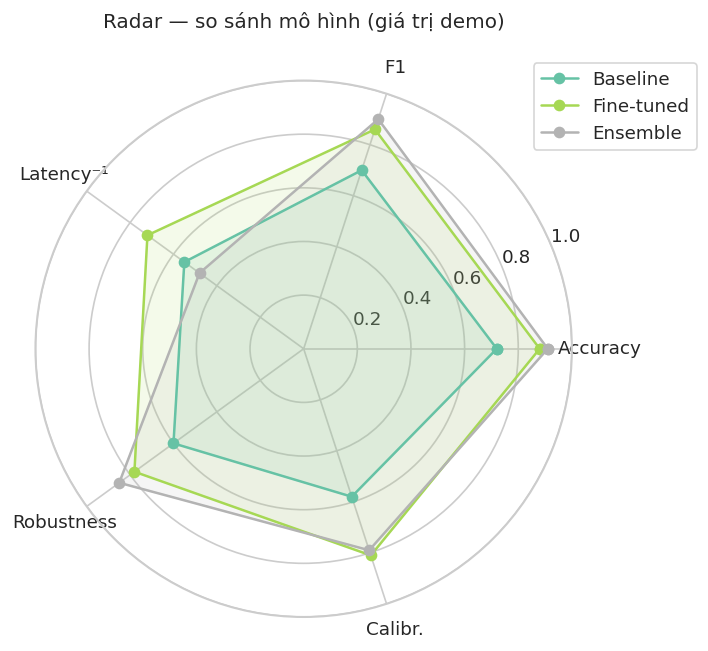

In [2]:
categories = ["Accuracy", "F1", "Latency⁻¹", "Robustness", "Calibr."]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

models = {
    "Baseline": np.array([0.72, 0.70, 0.55, 0.60, 0.58]),
    "Fine-tuned": np.array([0.88, 0.86, 0.72, 0.78, 0.81]),
    "Ensemble": np.array([0.91, 0.90, 0.48, 0.85, 0.79]),
}

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
for (name, values), c in zip(models.items(), colors):
    vals = np.concatenate([values, [values[0]]])
    ax.plot(angles, vals, "o-", linewidth=1.5, label=name, color=c)
    ax.fill(angles, vals, alpha=0.12, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Radar — so sánh mô hình (giá trị demo)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05))
plt.tight_layout()
fig.savefig(REPORTS / "viz_radar.png", bbox_inches="tight")
plt.show()

## 2. Bar chart — BERTScore (P / R / F1)

Dữ liệu dưới đây là **ví dụ**. Khi có kết quả thật, thay `scores` bằng output từ thư viện `bert-score` (hoặc CSV).

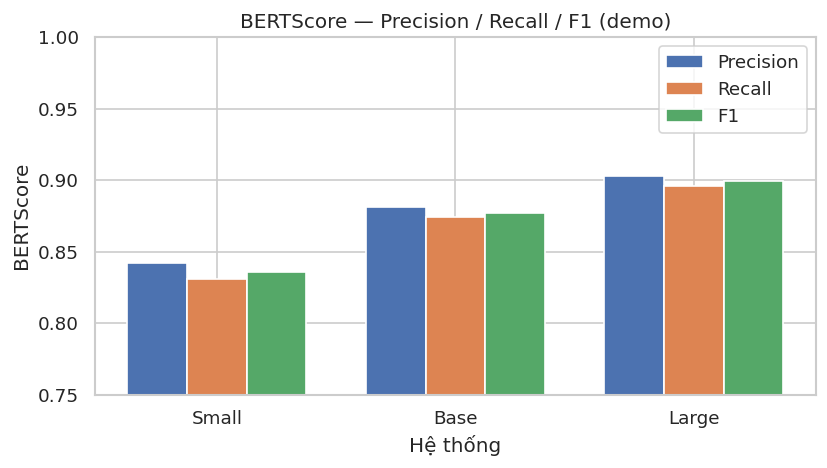

In [3]:
# Demo: thay bằng bert_score.score(cands, refs, lang='en') nếu cần
systems = ["Small", "Base", "Large"]
scores = {
    "Precision": [0.842, 0.881, 0.903],
    "Recall": [0.831, 0.874, 0.896],
    "F1": [0.836, 0.877, 0.899],
}

x = np.arange(len(systems))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
for i, (metric, vals) in enumerate(scores.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=metric)
ax.set_ylabel("BERTScore")
ax.set_xlabel("Hệ thống")
ax.set_xticks(x)
ax.set_xticklabels(systems)
ax.set_ylim(0.75, 1.0)
ax.set_title("BERTScore — Precision / Recall / F1 (demo)")
ax.legend()
plt.tight_layout()
fig.savefig(REPORTS / "viz_bertscore_bar.png", bbox_inches="tight")
plt.show()

## 3. Heatmap

Ma trận tương quan giữa các metric huấn luyện (dữ liệu giả lập).

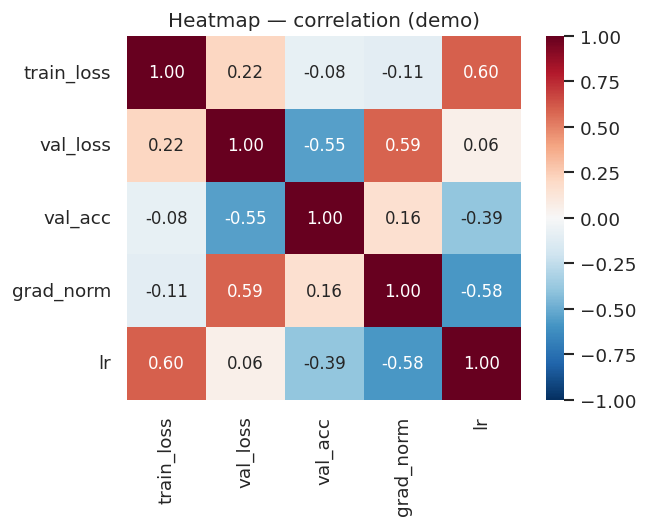

In [4]:
labels = ["train_loss", "val_loss", "val_acc", "grad_norm", "lr"]
base = RNG.standard_normal((5, 5))
corr = (base @ base.T) / 5
d = np.sqrt(np.clip(np.diag(corr), 1e-9, None))
corr = corr / d[:, None] / d[None, :]
np.fill_diagonal(corr, 1.0)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    corr,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Heatmap — correlation (demo)")
plt.tight_layout()
fig.savefig(REPORTS / "viz_heatmap.png", bbox_inches="tight")
plt.show()

## 4. 3D training plot

Trục: epoch → learning rate → validation loss (đường 3D qua các epoch).

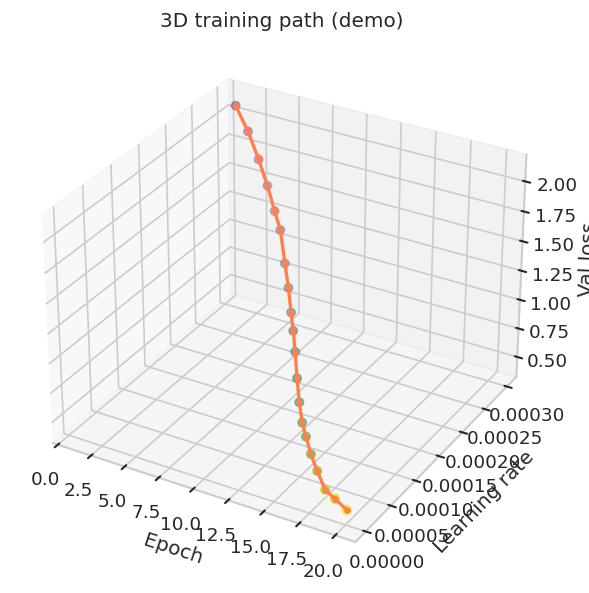

In [5]:
epochs = np.arange(1, 21)
lr = 3e-4 * (0.5 + 0.5 * np.cos(np.pi * (epochs - 1) / max(epochs)))
val_loss = 2.1 * np.exp(-0.12 * epochs) + 0.25 + RNG.normal(0, 0.03, size=epochs.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(epochs, lr, val_loss, color="coral", linewidth=2, marker="o", markersize=3)
ax.scatter(epochs, lr, val_loss, c=epochs, cmap="viridis", s=25, depthshade=True)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_zlabel("Val loss")
ax.set_title("3D training path (demo)")
plt.tight_layout()
fig.savefig(REPORTS / "viz_training_3d.png", bbox_inches="tight")
plt.show()

## 5. Training curves — Accuracy & Loss

Hai trục Y: accuracy (trái), loss (phải) cho train / validation.

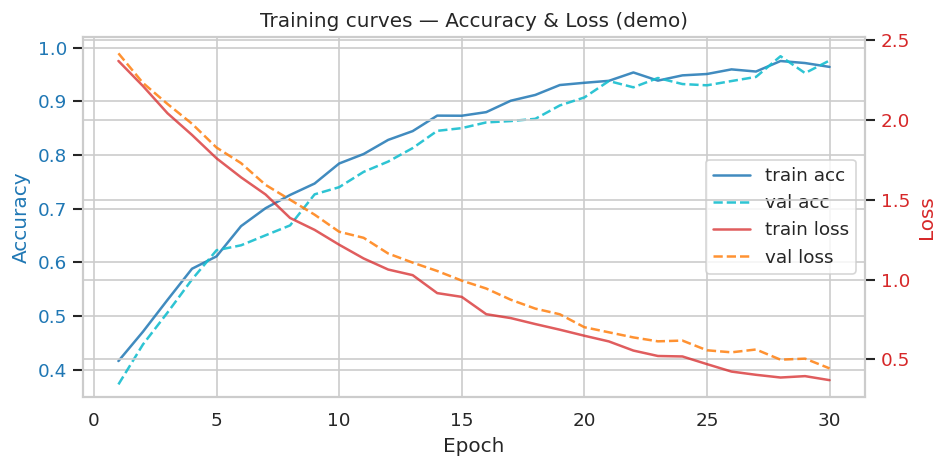

In [6]:
ep = np.arange(1, 31)
train_loss = 2.4 * np.exp(-0.08 * ep) + 0.15 + RNG.normal(0, 0.02, ep.size)
val_loss = 2.35 * np.exp(-0.075 * ep) + 0.22 + RNG.normal(0, 0.025, ep.size)
train_acc = 1 - 0.65 * np.exp(-0.11 * ep) + RNG.normal(0, 0.008, ep.size)
val_acc = 1 - 0.68 * np.exp(-0.10 * ep) + RNG.normal(0, 0.012, ep.size)
train_acc = np.clip(train_acc, 0, 1)
val_acc = np.clip(val_acc, 0, 1)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy", color="tab:blue")
ax1.plot(ep, train_acc, "-", color="tab:blue", alpha=0.85, label="train acc")
ax1.plot(ep, val_acc, "--", color="tab:cyan", alpha=0.9, label="val acc")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0.35, 1.02)

ax2 = ax1.twinx()
ax2.set_ylabel("Loss", color="tab:red")
ax2.plot(ep, train_loss, "-", color="tab:red", alpha=0.75, label="train loss")
ax2.plot(ep, val_loss, "--", color="tab:orange", alpha=0.85, label="val loss")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="center right")
ax1.set_title("Training curves — Accuracy & Loss (demo)")
plt.tight_layout()
fig.savefig(REPORTS / "viz_training_curves.png", bbox_inches="tight")
plt.show()

## 6. t-SNE visualization

Embedding 2D của **Digits** (64 chiều) — thay bằng vector đặc trưng từ mạng của bạn nếu cần.

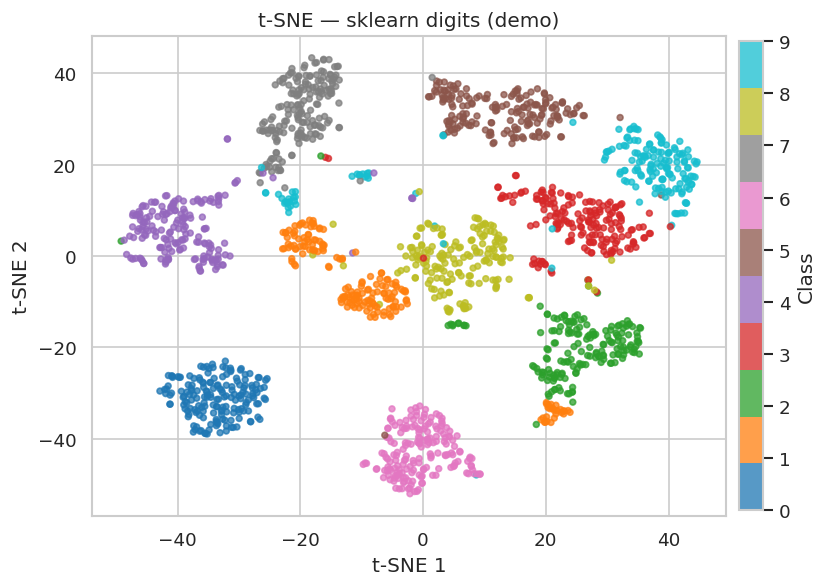

In [7]:
digits = load_digits()
X, y = digits.data, digits.target
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
Z = tsne.fit_transform(Xz)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=12, alpha=0.75)
ax.set_title("t-SNE — sklearn digits (demo)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
cbar = plt.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Class")
plt.tight_layout()
fig.savefig(REPORTS / "viz_tsne.png", bbox_inches="tight")
plt.show()